<a href="https://colab.research.google.com/github/RachitChowhan295/SoC-ADPLL-Final/blob/main/HighFreq%20ADPLL%20Mathematicall%20Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Our Goal is the match the refernce clock and DCO clock in terms of phase

The loop initially recieves the input reference clock. There is also a DCO clock running in the loop, this clock has already gone through-


*   Mash Modulator
*   Fractional Divider

The phase detector sees these 2 inputs and gives out the signal which is proportional to the error in the phases of these clocks-


*   If the DCO runs too fast φ_error>0
*   else the φ_error<0

The MASH 1-1 modulator (will be used later) sends a signal which consists of  predictable phase jumps which will destroy the output over time. This is calculated by the DTC to creat φ_fract when subtracted-

φ_res=φ_error-φ_fract

The next phase TDC puts these φ_res into bins, thus converting these small errors in radians into whole numbers, these numbers can be +/-. The signal passes through the CIC filter which takes a average of these whole numbers thus acting as a low pass filter here DECIM=4 means it averages 4 samples, thus the loop has a less noisy signal

Overall in the loop we have implemented a dynamic bandwidth which agressively ttacks the signal initally and allows more delicate and milder corrections later, based on the number of cycles passing

The signal then enters the PI filter where the Ki, Kp values are used to calculate the cntrl_word, this is the final error control which smoothens out the signal by acting as a dampener

The DCO finally converts the signal into the required frequency using DCO gain Ko and ctrl_word

Next step in the flow is to divide the signal, this provides allows the system to work towards maintaining the f_reference=Nxf_output

Here is where our Mash modulator works to get a integer n. Since it is impossible to divide signal by decimal numbers N. This is because the "division" in hardware is outputing a certain number of signals at a frequency after reciving a proportional number as input. Since signals are binary, n has to be integer

The MASH 1-1 modulator uses some cleaver maths to cancel the input noise. It consists of 2 phases-


*   Stage 1 Output: 𝐘 = 𝐅 + e_1(1-z^(-1))
*   Stage 2 Output: 𝐘 = - e_1 + e_2(1-z^(-1))

When the digital logic combines them to create the final division control signal \(Y\), it calculates:

𝐘 = 𝐘_(1)+𝐘_(2)(1-z^(-1))

The terms cancel out perfectly to form-

𝐘 =𝐅+e_(2)(1-z^(-1))^(2)

here e_1 is the noise that cancels out thus reducing the total noise output. The first stage uses the whole number part and the second stage accumalates the fraction and changes its output once a whole number is formed. Together the signals over many clock cycles average out to the required fraction.

Thus feedback is sent and the process takes place all over again. To sum it up-

*The DCO generates a clock whose frequency is adjusted by a PI controller. The output is fractionally divided using a MASH modulator and fed back to the phase detector. The detector measures phase difference between the feedback clock and the reference clock. A DTC removes predictable fractional-divider-induced phase shifts, a TDC digitizes the remaining error, a CIC filter suppresses high-frequency quantization noise, and a dynamically tuned PI loop filter computes a new control word for the DCO. This process repeats continuously until the divided DCO clock becomes phase-aligned with the reference clock, at which point the ADPLL is locked.*





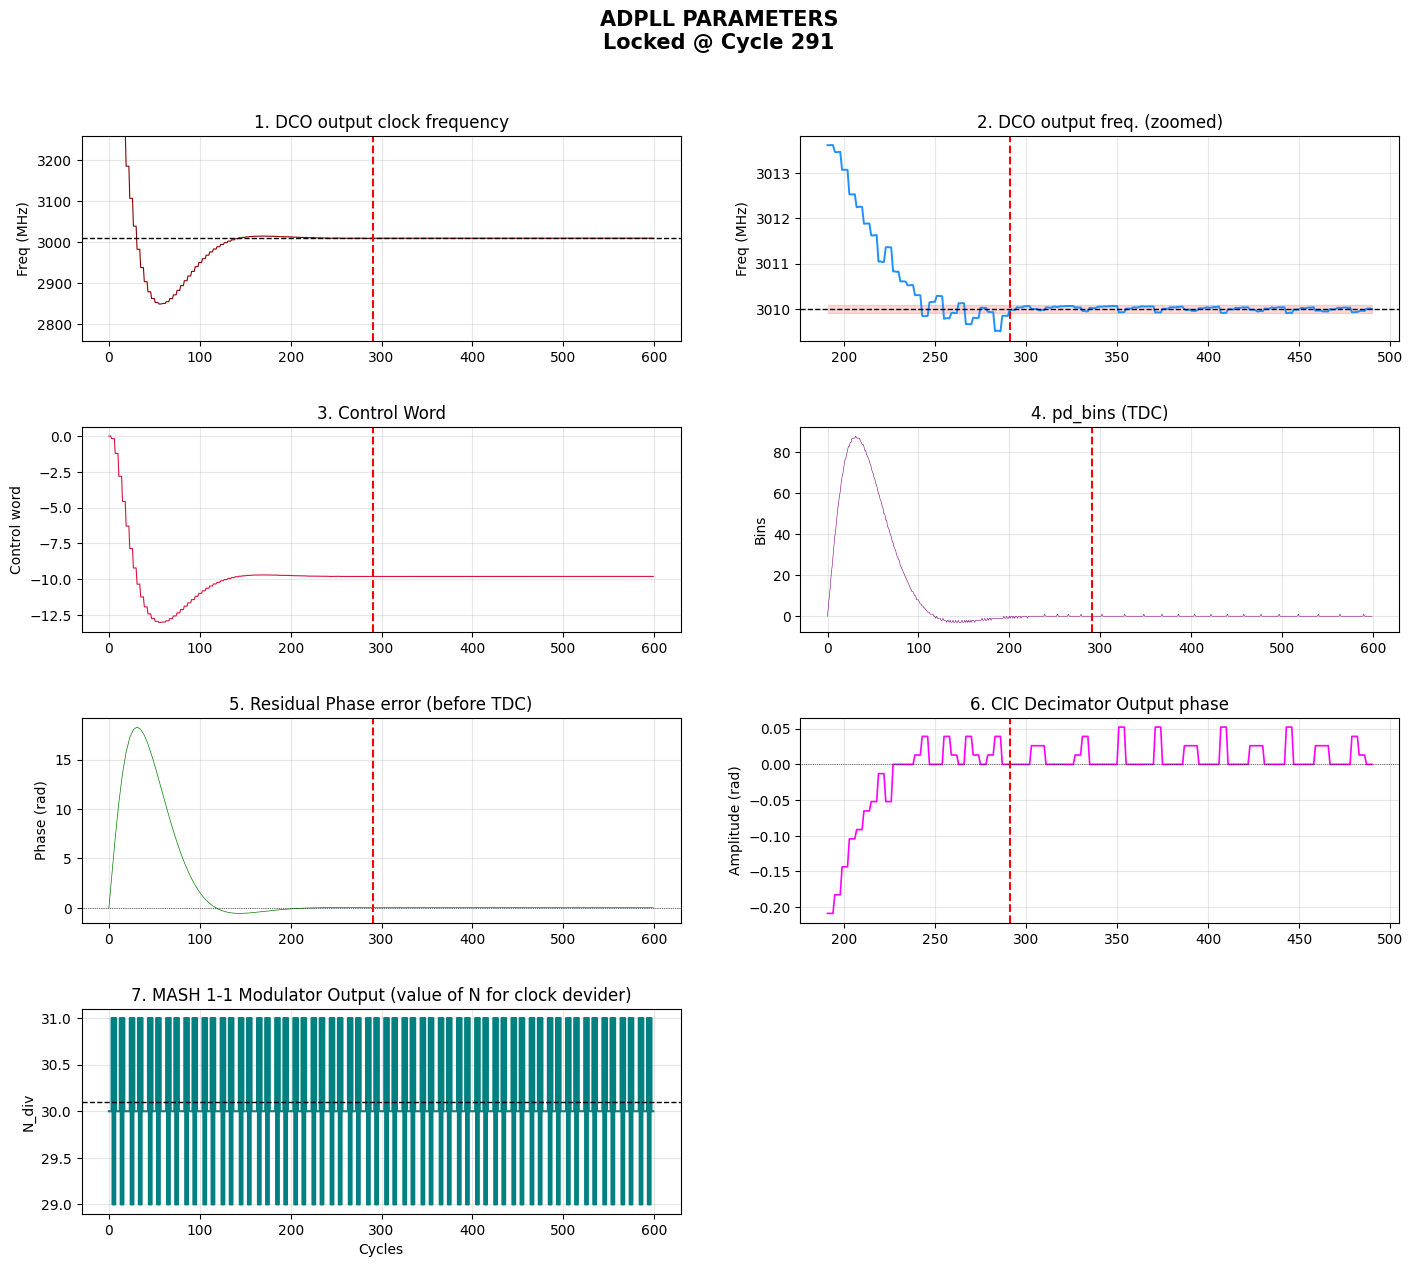

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from fractions import Fraction

# ─────────────────────────────────────────────────
# SYSTEM PARAMETERS
# ─────────────────────────────────────────────────
f_ref    = 100e6       #reference frequency for PLL model
f_free   = 3.5e9       #free running frequency for DCO
target_freq = 3.01e9   #target frequency for the PLL model
N        = target_freq / f_ref  #frequency multiplication factor
KO_GAIN  = 50e6     #DCO gain
n_cycles = 600      #No. of cycles the simulation runs

target_mhz  = target_freq / 1e6   #taget freq. in MHz

# TDC resolution
f_vco_nom  = target_freq
rad_res    = 2 * np.pi * f_ref / f_vco_nom   #TDC resolution in terms of phase
max_bins   = 128                             #number of TDC bins

# PI Loop filter variables
base_fn     = 10e3    # base Loop frequency (Bandwidth)
target_zeta = 0.707   #for damping

def update_loop_gains(bw_scale):
    omega_n = 2 * np.pi * base_fn * bw_scale
    Kp = (2 * target_zeta * omega_n * N) / (2 * np.pi * KO_GAIN)
    Ki = (omega_n**2 * N)                / (2 * np.pi * KO_GAIN * f_ref)
    return Kp, Ki

# ─────────────────────────────────────────────────
# STATE INITIALISATION
# ─────────────────────────────────────────────────
actual_phase_error = 0.0
fractional_phase   = 0.0
tdc_quant_err      = 0.0

integrator     = 0.0
ctrl_word_prev = 0.0
ctrl_word      = 0.0
freq_dco       = f_free

N_int  = int(np.floor(N))   #integer part of frequency multiplication factor
frac  = N - N_int           #fractional part of frequency multiplication factor
f_val = Fraction(frac).limit_denominator(100)  #coverting frac to a fraction
K_mod = f_val.numerator     #numerator of frac
F_mod = f_val.denominator   #denominator of frac

#for MASH Modulator
m1_int  = 0
m2_int  = 0
c2_prev = 0

# for Sinc^2/ CIC Decimator
DECIM    = 4
acc1     = 0.0
acc2     = 0.0
acc2_z1  = 0.0
diff1_z1 = 0.0

# ── Logging & Lock Detection ────────────────────
phase_error_log = np.zeros(n_cycles)
residual_log    = np.zeros(n_cycles)
freq_log        = np.zeros(n_cycles)
ctrl_log       = np.zeros(n_cycles)
tdc_bins_log   = np.zeros(n_cycles)
cic_out_log    = np.zeros(n_cycles)
sdm_log        = np.zeros(n_cycles)


lock_cycle     = None
LOCK_TOL_MHZ   = 0.08    # ±80 kHz lock tolerance window
lock_consec    = 0       # To chceck for how many consecutive cycles the lock is maintained
REQUIRED_CYCLES = 50     # Must stay inside window for 50 cycles to be "locked"

phi_err =0     # final error to update integrator

# ─────────────────────────────────────────────────
# MAIN SIMULATION LOOP
# ─────────────────────────────────────────────────
for i in range(n_cycles):

    # 1. DYNAMIC BANDWIDTH CHANGING
    if   i <  300: bw_scale = 50.0   # 500 kHz BW:  Wider bandwidth to reduce error faster
    elif i <  800: bw_scale = 10.0   # 100 kHz BW: Medium bandwidth
    else:          bw_scale = 1.0    #  10 kHz BW: Narrow bandwidth to track smoothly

    Kp, Ki = update_loop_gains(bw_scale)

    # 2. DTC FRACTIONAL-PHASE CANCELLATION
    exact_m1 = m1_int / F_mod
    fractional_phase = 2.0 * np.pi * (exact_m1 - c2_prev) / N
    residual_error = actual_phase_error - fractional_phase

    # 3. TDC
    tdc_input = residual_error + tdc_quant_err
    pd_bins   = np.round(tdc_input / rad_res)
    pd_bins   = np.clip(pd_bins, -max_bins, max_bins)
    pd_out    = pd_bins * rad_res
    tdc_quant_err = tdc_input - pd_out

    # 4. CIC Decimator (decimation by 4)
    acc1 += pd_out
    acc2 += acc1

    do_update = False
    if (i % DECIM) == (DECIM - 1):
        diff1 = acc2 - acc2_z1
        acc2_z1 = acc2

        diff2 = diff1 - diff1_z1
        diff1_z1 = diff1

        phi_err = diff2 / (DECIM**2)
        do_update = True

    # 5. TYPE-II PI DIGITAL LOOP FILTER
    if do_update:
        integrator    -= Ki * phi_err * DECIM
        pi_out         = integrator - Kp * phi_err

        alpha          = 0.6
        ctrl_word      = alpha * pi_out + (1.0 - alpha) * ctrl_word_prev
        ctrl_word_prev = ctrl_word

    # 6. LC-VCO MODEL
    dco_noise = np.random.normal(0, 5e3)
    freq_dco  = f_free + KO_GAIN * ctrl_word + dco_noise

    # 7. MASH 1-1 SDM
    m1_int += K_mod
    c1      = m1_int // F_mod
    m1_int  = m1_int  % F_mod

    m2_int += m1_int
    c2      = m2_int // F_mod
    m2_int  = m2_int  % F_mod

    sdm_out = c1 + (c2 - c2_prev)
    c2_prev = c2
    N_div   = max(1, N_int + sdm_out)

    # 8. PHYSICAL PHASE ACCUMULATION
    FERR = (freq_dco / f_ref) - N_div
    actual_phase_error += (2.0 * np.pi / N) * FERR

    # 9. LOGGING & LOCK DETECTION
    phase_error_log[i] = actual_phase_error
    residual_log[i]    = residual_error

    current_freq_mhz = freq_dco / 1e6
    freq_log[i] = current_freq_mhz
    ctrl_log[i]        = ctrl_word
    tdc_bins_log[i]    = pd_bins
    cic_out_log[i]     = phi_err
    sdm_log[i]         = N_div

    if lock_cycle is None:
        if abs(current_freq_mhz - target_mhz) < LOCK_TOL_MHZ:
            lock_consec += 1
            if lock_consec >= REQUIRED_CYCLES:
                # Stamp the cycle where it first entered the window
                lock_cycle = i - REQUIRED_CYCLES + 1
        else:
            lock_consec = 0

# Fallback if it never locks
if lock_cycle is None:
    lock_cycle = n_cycles - 1

# ==================================================
# PLOTTING GRAPHS
# ==================================================
fig = plt.figure(figsize=(17, 14))
fig.suptitle(f"ADPLL PARAMETERS\n"
             f"Locked @ Cycle {lock_cycle}", fontsize=15, fontweight='bold', y=0.97)

gs     = gridspec.GridSpec(4, 2, figure=fig, hspace=0.42, wspace=0.20)
cycles = np.arange(n_cycles)
lkw    = dict(color='red', lw=1.5, ls='--')

# 1. DCO output frequency
ax0 = fig.add_subplot(gs[0, 0])
ax0.plot(cycles, freq_log, lw=0.8, color='darkred')
ax0.axhline(target_freq / 1e6, color='black', lw=1.0, ls='--')
ax0.axvline(lock_cycle, **lkw)
ax0.set_title("1. DCO output clock frequency")

target_mhz = target_freq / 1e6
margin = 250.0
ax0.set_ylim(target_mhz - margin, target_mhz + margin)

ax0.set_ylabel("Freq (MHz)"); ax0.grid(True, alpha=0.3)

# 2. Convergence Zoom
ax1 = fig.add_subplot(gs[0, 1])
z_s = max(0, lock_cycle - 100); z_e = min(n_cycles, lock_cycle + 200)
ax1.plot(cycles[z_s:z_e], freq_log[z_s:z_e], lw=1.4, color='dodgerblue')
ax1.axhline(target_freq / 1e6, color='black', lw=1.0, ls='--')
ax1.axvline(lock_cycle, **lkw)
ax1.fill_between(cycles[z_s:z_e], target_freq/1e6 - LOCK_TOL_MHZ, target_freq/1e6 + LOCK_TOL_MHZ, alpha=0.15, color='red')
ax1.set_title("2. DCO output freq. (zoomed)")
ax1.set_ylabel("Freq (MHz)"); ax1.grid(True, alpha=0.3)

# 3. Control Word
ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(cycles, ctrl_log, lw=0.8, color='crimson')
#ax2.axhline(ctrl_preload, color='blue', lw=1.0, ls=':')
ax2.axvline(lock_cycle, **lkw)
ax2.set_title("3. Control Word")
ax2.set_ylabel("Control word"); ax2.grid(True, alpha=0.3)

# 4. TDC Bins
ax3 = fig.add_subplot(gs[1, 1])
ax3.plot(cycles, tdc_bins_log, lw=0.4, color='purple')
ax3.axvline(lock_cycle, **lkw)
ax3.set_title("4. pd_bins (TDC)")
ax3.set_ylabel("Bins"); ax3.grid(True, alpha=0.3)

# 5. Residual Phase
ax4 = fig.add_subplot(gs[2, 0])
ax4.plot(cycles, residual_log, lw=0.5, color='green')
ax4.axhline(0, color='black', lw=0.5, ls=':')
ax4.axvline(lock_cycle, **lkw)
ax4.set_title("5. Residual Phase error (before TDC)")
ax4.set_ylabel("Phase (rad)"); ax4.grid(True, alpha=0.3)

# 6. CIC Filter Output
ax5 = fig.add_subplot(gs[2, 1])
ax5.plot(cycles[z_s:z_e], cic_out_log[z_s:z_e], lw=1.2, color='magenta')
ax5.axhline(0, color='black', lw=0.5, ls=':')
ax5.axvline(lock_cycle, **lkw)
ax5.set_title("6. CIC Decimator Output phase")
ax5.set_ylabel("Amplitude (rad)"); ax5.grid(True, alpha=0.3)

# 7. MASH Modulator
ss = max(lock_cycle + 50, n_cycles - 150); se = min(ss + 60, n_cycles)
ax7 = fig.add_subplot(gs[3, 0])
ax7.step(cycles, sdm_log, lw=1.5, color='teal', where='post')
ax7.axhline(N, color='black', ls='--', lw=1.0)
ax7.set_title("7. MASH 1-1 Modulator Output (value of N for clock devider)")
ax7.set_ylabel("N_div"); ax7.set_xlabel("Cycles"); ax7.grid(True, alpha=0.3)

plt.show()